In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv('daily_sales.csv')
df.head()

,product_id,date,sales
0,P001,2023-01-01,56
1,P001,2023-01-02,35
2,P001,2023-01-03,44
3,P001,2023-01-04,45
4,P001,2023-01-05,30


In [3]:
df.shape

(2921, 3)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2921 entries, 0 to 2920
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   product_id  2921 non-null   object
 1   date        2921 non-null   object
 2   sales       2921 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 68.6+ KB


In [7]:
df.describe()

,sales
count,2921.000000
mean,68.137624
std,1654.505533
min,-5.000000
25%,7.000000
50%,36.000000
75%,50.000000
max,88888.000000


In [8]:
df["date"] = pd.to_datetime(df["date"])

In [10]:
X = df[["sales"]]

model = IsolationForest(contamination=0.05, random_state=42)

df["anomaly"] = model.fit_predict(X)

In [11]:
df["status"] = df["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

print(df.head())

  product_id       date  sales  anomaly  status
0       P001 2023-01-01     56        1  Normal
1       P001 2023-01-02     35        1  Normal
2       P001 2023-01-03     44        1  Normal
3       P001 2023-01-04     45        1  Normal
4       P001 2023-01-05     30        1  Normal


In [12]:
anomalies = df[df["anomaly"] == -1]
anomalies

,product_id,date,sales,anomaly,status
72,P001,2023-03-14,432,-1,Anomaly
219,P001,2023-08-08,9999,-1,Anomaly
548,P001,2024-07-02,490,-1,Anomaly
676,P001,2024-11-09,79,-1,Anomaly
677,P001,2024-11-10,78,-1,Anomaly
...,...,...,...,...,...
2885,P004,2024-11-26,11,-1,Anomaly
2894,P004,2024-12-05,13,-1,Anomaly
2900,P004,2024-12-11,13,-1,Anomaly
2905,P004,2024-12-16,12,-1,Anomaly


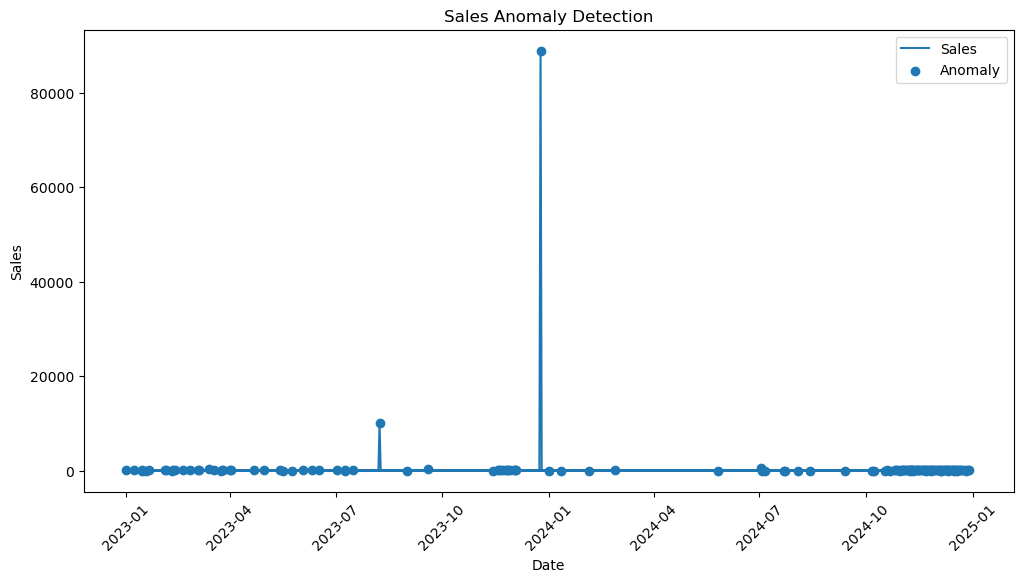

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["sales"], label="Sales")

anomaly_data = df[df["anomaly"] == -1]

plt.scatter(
    anomaly_data["date"],
    anomaly_data["sales"],
    label="Anomaly"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Anomaly Detection")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Model 1 Answers "Which sales values are globally unusual?"

In [25]:
df["date"] = pd.to_datetime(df["date"])

df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

df = df.sort_values(["product_id", "date"])

# rolling_std helps the model understand whether a sales value is far outside the product's normal variation.
df["rolling_mean"] = (
    df.groupby("product_id")["sales"]
      .transform(lambda x: x.rolling(7, min_periods=1).mean())
) # calculates the average sales over the recent 7 observations for each product.

df["rolling_std"] = (
    df.groupby("product_id")["sales"]
      .transform(lambda x: x.rolling(7, min_periods=1).std())
) # Standard deviation tells us approximately how much the sales normally fluctuate.

In [26]:
X2 = df[
    [
        "sales",
        "rolling_mean",
        "rolling_std",
        "day_of_week",
        "month"
    ]
]

In [27]:
model2 = IsolationForest(
    contamination=0.05,
    random_state=42
)

model2.fit(X2)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [28]:
df["anomaly2"] = model2.predict(X2)

In [29]:
df["status2"] = df["anomaly2"].map({
    1: "Normal",
    -1: "Anomaly"
})

In [30]:
anomalies2 = df[df["anomaly2"] == -1]
anomalies2

,product_id,date,sales,anomaly,status,day_of_week,month,rolling_mean,rolling_std,anomaly2,status2
72,P001,2023-03-14,432,-1,Anomaly,1,3,98.714286,147.109613,-1,Anomaly
73,P001,2023-03-15,43,1,Normal,2,3,99.285714,146.846535,-1,Anomaly
74,P001,2023-03-16,41,1,Normal,3,3,99.714286,146.642098,-1,Anomaly
75,P001,2023-03-17,44,1,Normal,4,3,99.571429,146.704757,-1,Anomaly
76,P001,2023-03-18,53,1,Normal,5,3,99.428571,146.757007,-1,Anomaly
...,...,...,...,...,...,...,...,...,...,...,...
2614,P004,2024-02-29,25,1,Normal,3,2,53.285714,61.619029,-1,Anomaly
2615,P004,2024-03-01,18,1,Normal,4,3,52.000000,62.348483,-1,Anomaly
2616,P004,2024-03-02,37,1,Normal,5,3,51.285714,62.510571,-1,Anomaly
2617,P004,2024-03-03,39,1,Normal,6,3,51.285714,62.510571,-1,Anomaly


Model 2 Answers "Which sales records look unusual considering their recent pattern and time context?"

In [32]:
different = df[
    df["anomaly"] != df["anomaly2"]
]

different

,product_id,date,sales,anomaly,status,day_of_week,month,rolling_mean,rolling_std,anomaly2,status2
73,P001,2023-03-15,43,1,Normal,2,3,99.285714,146.846535,-1,Anomaly
74,P001,2023-03-16,41,1,Normal,3,3,99.714286,146.642098,-1,Anomaly
75,P001,2023-03-17,44,1,Normal,4,3,99.571429,146.704757,-1,Anomaly
76,P001,2023-03-18,53,1,Normal,5,3,99.428571,146.757007,-1,Anomaly
77,P001,2023-03-19,56,1,Normal,6,3,100.571429,146.320262,-1,Anomaly
...,...,...,...,...,...,...,...,...,...,...,...
2885,P004,2024-11-26,11,-1,Anomaly,1,11,20.857143,10.991339,1,Normal
2894,P004,2024-12-05,13,-1,Anomaly,3,12,21.000000,7.348469,1,Normal
2900,P004,2024-12-11,13,-1,Anomaly,2,12,18.857143,5.756983,1,Normal
2905,P004,2024-12-16,12,-1,Anomaly,0,12,19.571429,7.207800,1,Normal


In [1]:
summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Model 1 anomalies",
        "Model 2 anomalies",
        "Both models agree",
        "Models disagree"
    ],
    "Count": [
        len(df),
        (df["anomaly"] == -1).sum(),
        (df["anomaly2"] == -1).sum(),
        (df["anomaly"] == df["anomaly2"]).sum(),
        (df["anomaly"] != df["anomaly2"]).sum()
    ]
})

summary

NameError: name 'pd' is not defined